# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 3, <font color="orange">сложная часть</font>. Линейная и логистическая регрессии.


**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить телеграм-боту `@thetahat_ds25_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайн см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**. Если вы строите интерактивные графики, их стоит прислать в формате html.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания всем участникам списывания дается штраф -2 балла к итоговой оценке за семестр.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.

**Правила оформления теоретических задач:**

* Решения необходимо оформить в виде $\LaTeX$ в markdown-ячейках. Иные способы (в т.ч. фотографии) не принимаются.
* Если вы не знаете $\LaTeX$, используйте ИИ-инструменты для оформления черновика решения. Примеры были показаны на лекции 2 по ИИ-инструментам.
* **В решениях поясняйте, чем вы пользуетесь**, хотя бы кратко. 
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.


<b><font size="5" color="red">Важно!!! Правила заполнения ноутбука:</font></b>
* Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения задач.
* Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз.
* Отвечайте на вопросы, а также добавляйте новые ячейки в предложенных местах, которые обозначены `<...>`.
* В markdown-ячейка, содержащих описание задачи, находятся специальные отметки, которые <font color="red"><b>запрещается модифицировать</b></font>.
* При нарушении данных правил работа может получить 0 баллов.


**Баллы за задание:**

<b><font color="blue">Легкая часть</font></b> (достаточно на "хор"):

* Задачи 1-4: скачайте первый ноутбук с условием задания со страницы курса.

<b><font color="orange">Сложная часть</font></b> (необходимо на "отл"):

* Задача 5 &mdash; 80 баллов;
* Задача 6 &mdash; 70 баллов;
* Задача 7 &mdash; 50 баллов.

Баллы учитываются в <b>обязательной части</b> курса и не влияют на оценку по факультативной части.

In [ ]:
# Bot check

# HW_ID: fpmi_ad3_part2
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from typing import Literal

sns.set(style="whitegrid", palette="Set2")

При решении задания используйте `sklearn`. Пропишите сюда необходимые импорты

In [37]:
from sklearn.base import BaseEstimator
from sklearn.preprocessing import StandardScaler
from time import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.special import logsumexp
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator

from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

---
### <font color="blue"><i>Легкая часть</i></font>

Задачи 1-4: скачайте первый ноутбук с условием задания со страницы курса.

---
### <font color="orange"><i>Сложная часть</i></font>

---
### Задача 5.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- a33928f56f5dc26d8a6754dd7365e93a -->
**1.** Реализуйте логистическую регрессию для двух вариантов поиска оценки параметров:
* простой градиентный спуск;
* стохастический градиентный спуск с `batch_size` элементами на каждой итерации.

Останавливайте итерации при выполнении хотя бы одного из двух условий:
* количество итераций превзошло число `max_iter`;
* оптимизируемый функционал изменился за итерацию не более чем на `tol`.

При выполнении каждой итерации с целью дальнейшего анализа сохраняйте текущее значение оптимизируемого функционала, а также затраченное время на итерацию.  **При реализации класса запрещено пользоваться ИИ-инструментами.**

*Замечания.*

1. Для чистоты эксперимента время шага внутри цикла нужно замерять от конца предыдущего шага до конца текущего, а не от начала текущего шага. Время измеряйте с помощью `from time import time`.

2. Иногда при подсчете сигмоиды и оптимизируемого функционала могут возникать вычислительные ошибки. Для их избежания существуют специальные трюки.
    * [How to Evaluate the Logistic Loss and not NaN trying](http://fa.bianp.net/blog/2019/evaluate_logistic/)
    * [Exp-normalize trick](https://timvieira.github.io/blog/post/2014/02/11/exp-normalize-trick/)<br>
3. Трюки не обязательно реализовывать самостоятельно, можете воспользоваться функциями для них из `numpy` или `scipy`:
    * [`numpy.logaddexp`](https://numpy.org/doc/stable/reference/generated/numpy.logaddexp.html);
    * [`scipy.special.logsumexp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.logsumexp.html).
4. Обратите внимание, что класс `LogisticRegression` &mdash; наследник класса `BaseEstimator`, это с легкостью позволит использовать наш класс в различных пайплайнах библиотеки `sklearn`.
4. Следите за качеством кода, комментируйте логические этапы кода. Несоблюдение этого требования может привести к потере баллов.


In [3]:
class LogisticRegression(BaseEstimator):
    """Модель логистической регрессии.

    Параметры:
    method (Literal['gd', 'sgd']): Метод оптимизации ('gd' - градиентный спуск, 
        'sgd' - стохастический градиентный спуск).
    learning_rate (float): Константа скорости обучения, на которую домножаем градиент при обучении
    tol (float): Допустимое изменение функционала между итерациями.
    max_iter (int): Максимальное число итераций.
    batch_size (int): Размер выборки для оценки градиента (используется только при 'sgd').
    fit_intercept (bool): Добавлять ли константу в признаки.
    save_history (bool): Сохранять ли историю обучения.
    """

    def __init__(
        self,
        method: Literal["gd", "sgd"] = "gd",
        learning_rate: float = 0.5,
        tol: float = 1e-3,
        max_iter: int = int(1e4),
        batch_size: int = 64,
        fit_intercept: bool = True,
        save_history: bool = True,
    ):
        """Создает модель и инициализирует параметры."""
        self.method = method
        self.learning_rate = learning_rate
        self.tol = tol
        self.max_iter = max_iter
        self.batch_size = batch_size
        self.fit_intercept = fit_intercept
        self.save_history = save_history
        self.history = []  # История обучения

    @staticmethod
    def _sigmoid(x: np.ndarray) -> np.ndarray:
        """Вычисляет сигмоидную функцию."""
        # Используем logaddexp для численной устойчивости
        return np.exp(-np.logaddexp(0, -x))

    def _add_intercept(self, X: np.ndarray) -> np.ndarray:
        """Добавляет свободный коэффициент к матрице признаков.

        Параметры: X (np.ndarray): Исходная матрица признаков.

        Возвращает: np.ndarray: Матрица X с добавленным свободным
        коэффициентом.
        """
        if self.fit_intercept:
            return np.column_stack([X, np.ones(X.shape[0])])
        return X

    def fit(self, X: np.ndarray, Y: np.ndarray) -> "LogisticRegression":
        """Обучает модель логистической регрессии.

        Также, в случае self.save_history=True, добавляет в self.history
        текущее значение оптимизируемого функционала и затраченное время.

        Параметры:
        X (np.ndarray): Матрица признаков.
        Y (np.ndarray): Вектор истинных меток.

        Возвращает:
        LogisticRegression: Обученная модель.
        """
        if X.shape[0] != Y.shape[0]:
            raise ValueError("Количество строк в X и Y должно совпадать")

        X_copy = self._add_intercept(X)
        
        prev_loss = np.inf  # предыдущие потери бесконечны, это нужно для сравнения
        current_loss = 0
        idx = 0
        
        # Инициализация параметров
        # Если fit_intercept=True, последний элемент - intercept, остальные - coef_
        Theta = np.zeros(X_copy.shape[1], dtype=np.float64)
        
        # Преобразуем Y в numpy.ndarray, если это pandas.Series
        if hasattr(Y, 'to_numpy'):
            Y = Y.to_numpy()
        
        flag = True
        start_time = time()
        
        while flag and (idx < self.max_iter):
            # В случае стохастического градиентного спуска
            if self.method == "sgd":
                # Выбор батча С ПОВТОРЕНИЕМ (replace=True)
                batch_indices = np.random.choice(X_copy.shape[0], self.batch_size, replace=True)
                X_batch, y_batch = X_copy[batch_indices], Y[batch_indices]
                y_pred = self._sigmoid(X_batch @ Theta)
                error = y_pred - y_batch
                gradient = X_batch.T @ error / self.batch_size  # Нормировка на размер батча
            else:
                # Полный градиентный спуск
                y_pred = self._sigmoid(X_copy @ Theta)
                error = y_pred - Y
                gradient = X_copy.T @ error / X_copy.shape[0]  # Нормировка на размер выборки
            
            # Обновление параметров
            Theta -= self.learning_rate * gradient

            # Вычисление потерь
            if self.method == "gd":
                current_loss = -np.sum(Y * np.log(y_pred + 1e-15) + (1 - Y) * np.log(1 - y_pred + 1e-15)) / X_copy.shape[0]
            elif self.method == "sgd":
                current_loss = -np.sum(y_batch * np.log(y_pred + 1e-15) + (1 - y_batch) * np.log(1 - y_pred + 1e-15)) / self.batch_size
        
            # Сохранение истории
            if self.save_history:
                self.history.append({"loss": current_loss, "time": time() - start_time})
                
            # Проверка условия остановки
            if abs(prev_loss - current_loss) < self.tol:
                flag = False

            prev_loss = current_loss
            idx += 1
            start_time = time()

        # Правильное разделение коэффициентов и intercept
        if self.fit_intercept:
            self.coef_ = Theta[:-1]  # Все кроме последнего элемента - коэффициенты признаков
            self.intercept_ = Theta[-1]  # Последний элемент - intercept
        else:
            self.coef_ = Theta  # Все элементы - коэффициенты признаков
            self.intercept_ = 0.0  # Intercept явно равен 0

        self.n_iter_ = idx  # Число итераций

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Возвращает предсказанные классы.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Предсказанные классы.
        """
        X_copy = self._add_intercept(X)

        if X_copy.shape[1] != len(self.coef_) + (1 if self.fit_intercept else 0):
            raise ValueError("Число признаков в X не соответствует числу коэффициентов модели")

        if self.fit_intercept:
            linear_output = X @ self.coef_ + self.intercept_
        else:
            linear_output = X @ self.coef_

        predictions = (self._sigmoid(linear_output) >= 0.5).astype(int)
        return predictions

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Возвращает вероятности классов 0 и 1.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Матрица вероятностей классов (n_samples,
        2).
        """
        X_copy = self._add_intercept(X)

        if X_copy.shape[1] != len(self.coef_) + (1 if self.fit_intercept else 0):
            raise ValueError("Число признаков в X не соответствует числу коэффициентов модели")

        if self.fit_intercept:
            linear_output = X @ self.coef_ + self.intercept_
        else:
            linear_output = X @ self.coef_

        y_pred = self._sigmoid(linear_output)
        prob_predictions = np.column_stack([1 - y_pred, y_pred])
        return prob_predictions

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 00000000000000000000000000000000 -->
Рассмотрим датасет [Diabetes Health Indicators](https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset).

**Для данного задания будем рассматривать версию датасета** `diabetes_binary_5050split_health_indicators_BRFSS2015.csv`


Этот датасет содержит статистику здравоохранения и информацию об образе жизни, полученную в результате опросов вместе с меткой наличия/отсутствия диабета у участников. Среди признаков есть демографические данные, результаты лабораторных тестов и ответы на вопросы анкеты. Целевая переменная  `Diabetes_binary` определяет статус пациента: есть ли у него диабет или предиабет (`1`), или он здоров (`0`).



Рассмотрим некоторые признаки, представленные в датасете.

**Показатели здоровья**

- `HighBP`: Высокое кровяное давление (`1` = да, `0` = нет).

- `HighChol`: Высокий уровень холестерина (`1` = да, `0` = нет).

- `CholCheck`: Проверка уровня холестерина за последние 5 лет (`1` = да, `0` = нет).

- `BMI`: Индекс массы тела (рассчитывается как вес (кг) / рост² (м²)).

- `GenHlth`: Общая оценка здоровья (`1` = отличное, `2` = очень хорошее, ..., `5` = плохое).

**Образ жизни**
- `Smoker`: Статус курения (`1` = выкурил ≥100 сигарет за жизнь, `0` = нет).

- `PhysActivity`: Физическая активность вне работы (`1` = да, `0` = нет).

- `Fruits`: Регулярное употребление фруктов (`1` = не менее 1 раз в день, `0` = реже).

**Доступ к медицине**
- `AnyHealthcare`: Наличие медицинской страховки (`1` = да, `0` = нет).

- `NoDocbcCost`: Отказ от визита к врачу из-за стоимости (`1` = да, `0` = нет).



Скачайте файл и прочитайте его с помощью `pandas`.

In [4]:
dataset = pd.read_csv(r"D:\MIPT\Semester_4\AD\health\diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
dataset.head(6)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
5,0.0,0.0,0.0,1.0,18.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,2.0,7.0,0.0,0.0,0.0,1.0,4.0,7.0


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 2aaab795bfe3971fb1c1e61c48002808 -->
Разделите выборку на обучающую и тестовую и выполните преобразование категориальных признаков.

In [5]:
# разделим данные на обучающую и тестовую выборки с разделением целевого признака
X = dataset.drop(columns=["Diabetes_binary"])  # Признаки
y = dataset["Diabetes_binary"]  # Целевая переменная
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Разделим категориальные и вещественные признаки. В данном случае их можно разделить по наличию цифр после запятой.
categorical_features = ["HighBP", "HighChol", "CholCheck", "GenHlth", "Smoker", "PhysActivity", "Fruits", "AnyHealthcare", "NoDocbcCost"]
numeric_features = ["BMI"]

In [7]:
print("Обучающая выборка после преобразований:", X_train.shape)
print("Тестовая выборка после преобразований:", X_test.shape)

Обучающая выборка после преобразований: (56553, 21)
Тестовая выборка после преобразований: (14139, 21)


Для интерпретации коэффициентов необходимо нормализовать данные. Воспользуемся для этого классом `StandardScaler` из библиотеки `sklearn`.

In [8]:
# Нормализация данных
scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", scaler, numeric_features),  # Масштабирование числовых признаков
        ("cat", OneHotEncoder(), categorical_features)  # One-hot кодирование категориальных
    ]
)

In [9]:
# Применение преобразований к данным. Причем заново обучаем только на тренинг выборке.
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 107ac5fe506b9f95aacd88457e0ec142 -->
**2.** Обучите две модели логистической регрессии с помощью методов
* простой градиентный спуск;
* стохастический градиентный спуск.

In [10]:
# Обучение модели с простым градиентным спуском (GD)
model_gd = LogisticRegression(method="gd", learning_rate=0.1, max_iter=1000, tol=1e-4, save_history=True)
model_gd.fit(X_train, y_train)

LogisticRegression(learning_rate=0.1, max_iter=1000, tol=0.0001)

In [11]:
# со стохастическим
model_sgd = LogisticRegression(method="sgd", learning_rate=0.1, max_iter=1000, batch_size=64, tol=1e-4, save_history=True)
model_sgd.fit(X_train, y_train)

LogisticRegression(learning_rate=0.1, max_iter=1000, method='sgd', tol=0.0001)

Постройте график, на котором нанесите две кривые обучения, каждая из которых отображает зависимость оптимизируемого функционала от номера итерации метода. **Функционал должен быть одинаковый для всех моделей**. Нарисуйте также график зависимости этого функционала от времени работы метода. 

*Замечания:*
* Все графики должны быть информативны, с подписанными осями и т.д..
* Для чистоты эксперимента желательно не запускать в момент обучения другие задачи и провести обучение несколько раз, усреднив результаты.

In [12]:
# Функция для обучения и сбора истории с фиксированным числом итераций
def train_and_collect_history(method, n_runs=5, max_iter=1000):
    # Инициализация массивов для хранения результатов
    all_losses = np.zeros((n_runs, max_iter))
    all_times = np.zeros((n_runs, max_iter))
    
    for run in range(n_runs):
        if method == "gd":
            model = LogisticRegression(method="gd", learning_rate=0.1, 
                                     max_iter=max_iter, tol=1e-4, save_history=True)
        else:
            model = LogisticRegression(method="sgd", learning_rate=0.1, 
                                     max_iter=max_iter, batch_size=64, 
                                     tol=1e-4, save_history=True)
        
        model.fit(X_train, y_train)
        
        # Получаем историю
        losses = [entry["loss"] for entry in model.history]
        times = np.cumsum([entry["time"] for entry in model.history])
        
        # Заполняем массивы (обрезаем если история короче max_iter)
        n_iters = min(len(losses), max_iter)
        all_losses[run, :n_iters] = losses[:n_iters]
        all_times[run, :n_iters] = times[:n_iters]
        
        # Если история короче, повторяем последнее значение
        if n_iters < max_iter:
            all_losses[run, n_iters:] = losses[-1]
            all_times[run, n_iters:] = times[-1]
    
    # Усреднение результатов
    avg_losses = np.mean(all_losses, axis=0)
    avg_times = np.mean(all_times, axis=0)
    
    return avg_losses, avg_times

# Параметры обучения
max_iter = 500  # Уменьшим для скорости, можно увеличить
n_runs = 3      # Количество прогонов для усреднения

# Обучение моделей и сбор истории
gd_losses, gd_times = train_and_collect_history("gd", n_runs, max_iter)
sgd_losses, sgd_times = train_and_collect_history("sgd", n_runs, max_iter)

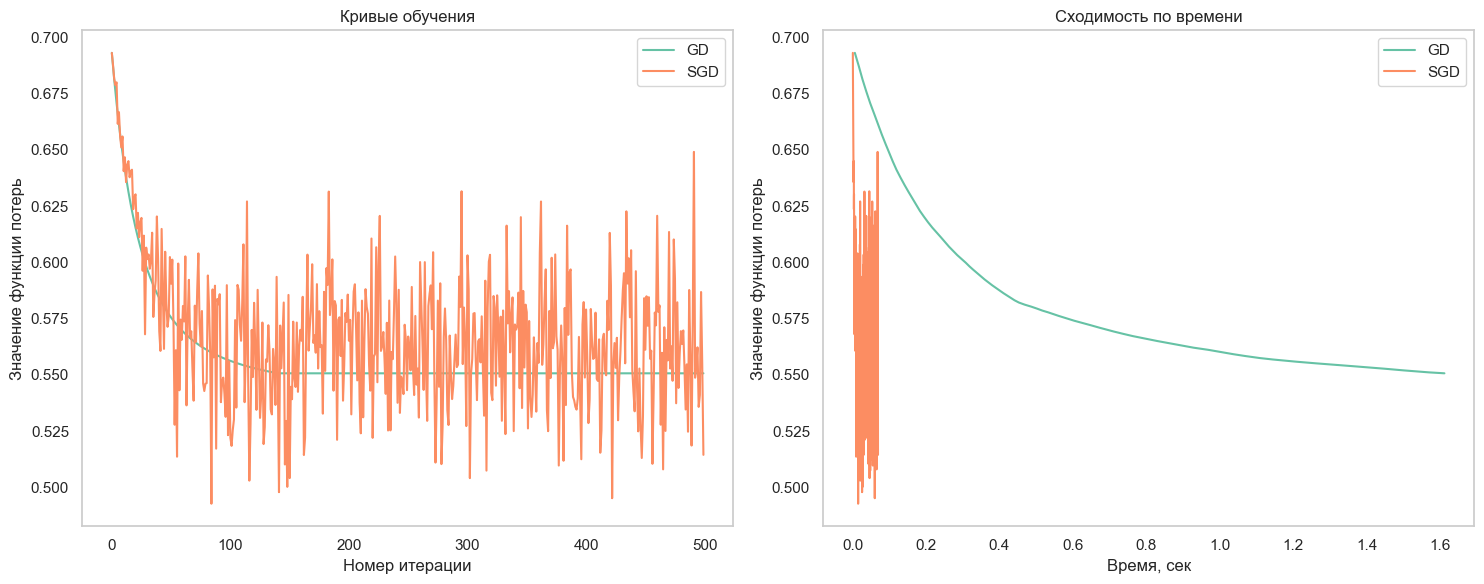

In [13]:
# Построение графиков
plt.figure(figsize=(15, 6))

# График зависимости потерь от итерации
plt.subplot(1, 2, 1)
plt.plot(range(max_iter), gd_losses, label="GD")
plt.plot(range(max_iter), sgd_losses, label="SGD")
plt.xlabel("Номер итерации")
plt.ylabel("Значение функции потерь")
plt.title("Кривые обучения")
plt.legend()
plt.grid()

# График зависимости потерь от времени
plt.subplot(1, 2, 2)
plt.plot(gd_times, gd_losses, label="GD")
plt.plot(sgd_times, sgd_losses, label="SGD")
plt.xlabel("Время, сек")
plt.ylabel("Значение функции потерь")
plt.title("Сходимость по времени")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

Сделайте выводы. Что будет при обучении на датасете, если  увеличить количество объектов, а число признаков оставить прежним?

Была построена логистическая модель с градиентным и стохастичесским градиентным спусками. SGD обучается быстрее, но более лабилен, и лосс в уонечном итоге устанавливается больший. При увеличении данных:
Оба метода улучшат качество. GD станет более стабильным, но медленным, SGD сохранит преимущество в скорости сходимости

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 4bb375127a9740dd293a61773746352d -->
**3.** Исследуйте влияние размер шага (`learning_rate`) на качество модели для двух режимов обучения (простой и стохастический градиентный спуск). Для каждого размера шага получите качество модели при использовании простого и стохастического градиентного спуска. Сравните качество полученных моделей по метрике `accuracy`.

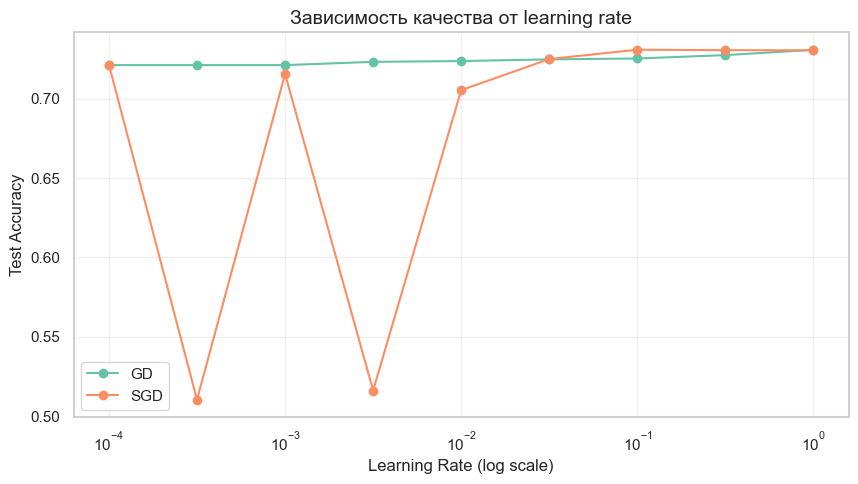

In [14]:
# Определение диапазона learning_rate (логарифмическая шкала)
learning_rates = np.logspace(-4, 0, 9)  # 0.0001, 0.001, ..., 1.0

# Обучение моделей и сбор accuracy
gd_acc, sgd_acc = [], []

for lr in learning_rates:
    # Градиентный спуск
    model_gd = LogisticRegression(
        method="gd", 
        learning_rate=lr, 
        max_iter=1000, 
        tol=1e-4
    ).fit(X_train, y_train)
    gd_acc.append(accuracy_score(y_test, model_gd.predict(X_test)))
    
    # Стохастический градиентный спуск
    model_sgd = LogisticRegression(
        method="sgd", 
        learning_rate=lr, 
        max_iter=1000, 
        batch_size=64, 
        tol=1e-4
    ).fit(X_train, y_train)
    sgd_acc.append(accuracy_score(y_test, model_sgd.predict(X_test)))

# Визуализация
plt.figure(figsize=(10, 5))
plt.plot(learning_rates, gd_acc, "o-", label="GD")
plt.plot(learning_rates, sgd_acc, "o-", label="SGD")
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.title("Зависимость качества от learning rate", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Сделайте выводы

Точность модели GD монотонно растёт с увеличением шага. Точность модели SGD колеблется, но в целом определяется возрастание, под конец выходит на плато. Лучшими значениями можно считать lr ~ 1.0

Постройте кривые обучения для различных `learning_rate`. Не обязательно рассматривать все `learning_rate`, так как их слишком много, и график будет нагроможден. Возьмите около половины из них.

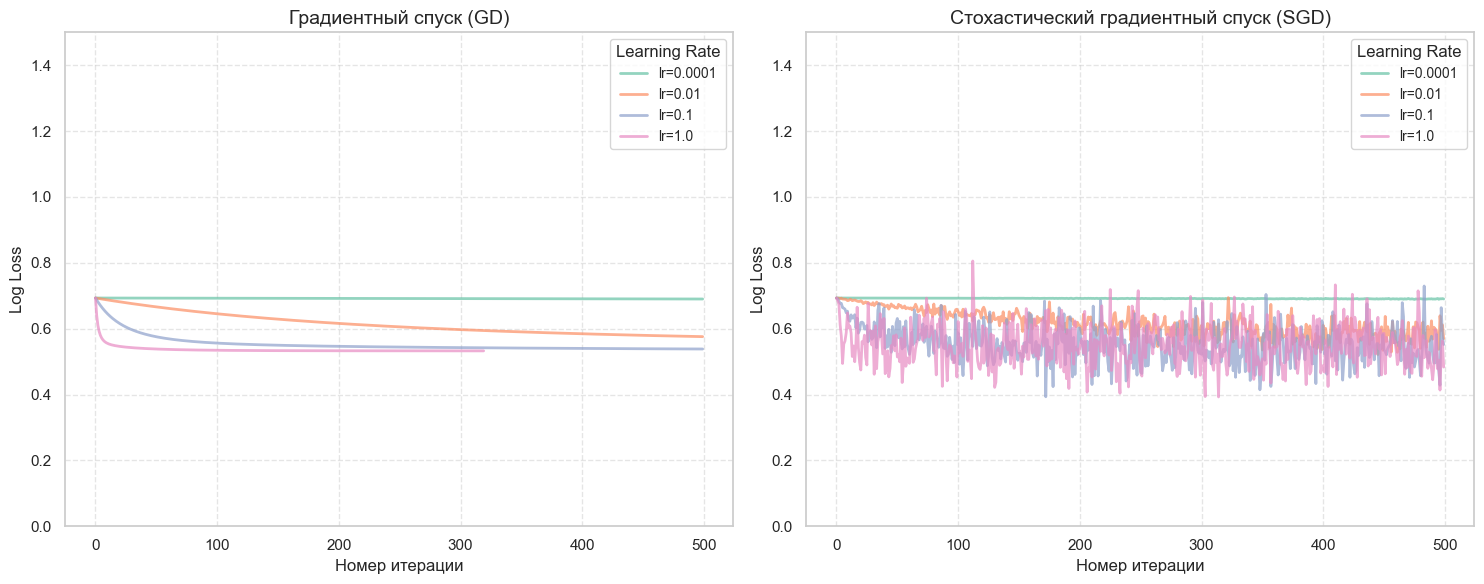

In [15]:
selected_lr = [0.0001, 0.01, 0.1, 1.0]  # Выбранные learning rates

plt.figure(figsize=(15, 6))

# График для Gradient Descent
plt.subplot(1, 2, 1)
for lr in selected_lr:
    model = LogisticRegression(
        method="gd",
        learning_rate=lr,
        max_iter=500,
        save_history=True,
        tol=1e-6
    )
    model.fit(X_train, y_train)
    losses = [entry["loss"] for entry in model.history]
    plt.plot(losses, label=f"lr={lr}", alpha=0.7, linewidth=2)
    
plt.xlabel("Номер итерации", fontsize=12)
plt.ylabel("Log Loss", fontsize=12)
plt.title("Градиентный спуск (GD)", fontsize=14)
plt.legend(title="Learning Rate", fontsize=10)
plt.grid(linestyle="--", alpha=0.5)
plt.ylim(0, 1.5)  # Фиксируем масштаб для сравнения

# График для Stochastic Gradient Descent
plt.subplot(1, 2, 2)
for lr in selected_lr:
    model = LogisticRegression(
        method="sgd",
        learning_rate=lr,
        max_iter=500,
        batch_size=64,
        save_history=True,
        tol=1e-9
    )
    model.fit(X_train, y_train)
    losses = [entry["loss"] for entry in model.history]
    plt.plot(losses, label=f"lr={lr}", alpha=0.7, linewidth=2)

plt.xlabel("Номер итерации", fontsize=12)
plt.ylabel("Log Loss", fontsize=12)
plt.title("Стохастический градиентный спуск (SGD)", fontsize=14)
plt.legend(title="Learning Rate", fontsize=10)
plt.grid(linestyle="--", alpha=0.5)
plt.ylim(0, 1.5)  # Единый масштаб с GD

plt.tight_layout()
plt.show()

Какой `learning_rate` стоит выбирать в зависимости от способа обучения модели? Чем плохи маленькие и большие `learning_rate`?

Для GD 1.0, для SGD 0.0, потому что лосс в GD быстрее достигает минимального значения среди всех лоссов, а 0.01 в SGD гораздо более стабилен, хотя и медленне достигает минимума лосса.

Большие волатильны в SGD. Маленькие застревают в локальных ямах.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- ff32f56c5ac017a9bbd819e9d918bf17 -->
**4.** Рассмотрите наилучшую модель с предыдущего шага. Визуализируйте значения полученных коэффициентов.

In [16]:
# разделим данные на обучающую и тестовую выборки с разделением целевого признака
X = dataset.drop(columns=["Diabetes_binary"])  # Признаки
y = dataset["Diabetes_binary"]  # Целевая переменная
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

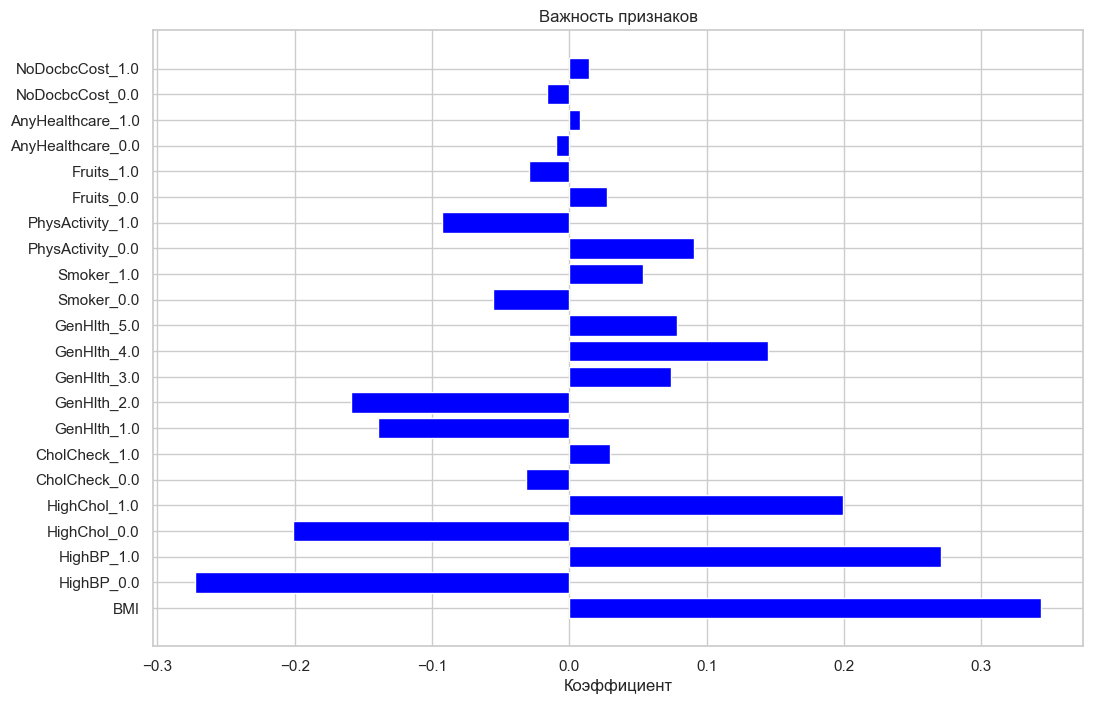

In [17]:
# Сохраняем исходные данные до преобразования
X_train_original = X_train.copy()
X_test_original = X_test.copy()

# Применяем преобразования
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(), categorical_features)
    ]
)
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Обучаем модель на преобразованных данных
best_model = LogisticRegression(method="gd", learning_rate=0.1).fit(X_train_scaled, y_train)

# Извлекаем имена признаков
cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_features = numeric_features + list(cat_features)

# Визуализация
plt.figure(figsize=(12, 8))
plt.barh(all_features, best_model.coef_, color="blue")
plt.xlabel("Коэффициент")
plt.title("Важность признаков")
plt.show()

Как можно проинтерпретировать полученные результаты относительно решаемой задачи?

Больше всего на прогноз влияют такие показатели, как: BMI, High_BP, HighCol. Средний вклад вносят: Gen_hlth, Phys_activity, Smoker. Наименьший вклад дают: Chol_check, Fruits, AnyHealthCare, Nodocbccost.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- d9db1dced64c0f75bb370e31595d818c -->
**5.** Сравните данную модель с бейзлайном, который в качестве предсказания выдает самый частый класс на обучающей выборке.

In [18]:
# бейзлайн
baseline_pred = np.random.randint(0, 2, size=len(y_test))
baseline_accuracy = accuracy_score(y_test, baseline_pred)

Наша модель:

In [19]:
# 2. Лучшая модель (GD с learning_rate=1.0)
best_model_gd = LogisticRegression(
    method="gd",
    learning_rate=1.0,    
    max_iter=1000,        
    tol=-1,             
    save_history=False
).fit(X_train_scaled, y_train)

Достигнут максимум итераций (1000)

Результаты:
Accuracy бейзлайна: 0.503
Accuracy GD (lr=1.0): 0.731
Разница: 0.228


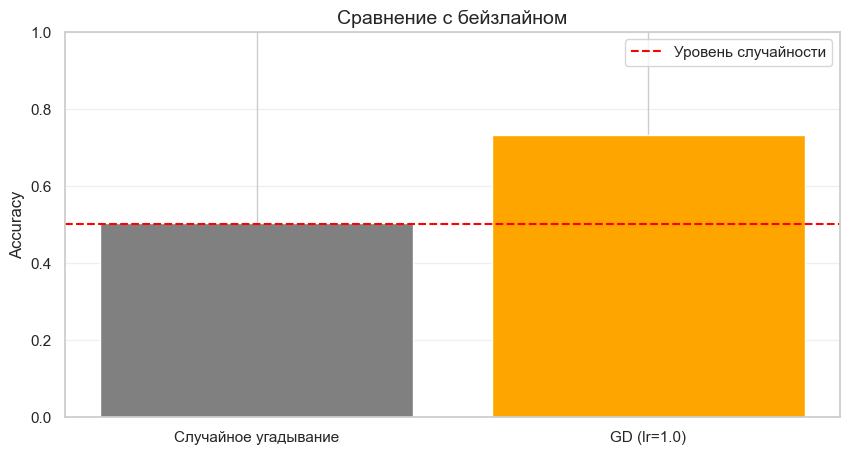

In [20]:
# Предсказания модели
model_pred = best_model_gd.predict(X_test_scaled)
model_accuracy = accuracy_score(y_test, model_pred)

# история обучения
if best_model_gd.n_iter_ < best_model_gd.max_iter:
    print(f"Обучение остановлено на {best_model_gd.n_iter_} итерациях (изменение loss < {best_model_gd.tol})")
else:
    print(f"Достигнут максимум итераций ({best_model_gd.max_iter})")

# Сравнение с бейзлайном
print("\nРезультаты:")
print(f"Accuracy бейзлайна: {baseline_accuracy:.3f}")
print(f"Accuracy GD (lr=1.0): {model_accuracy:.3f}")
print(f"Разница: {model_accuracy - baseline_accuracy:.3f}")

# Визуализация
plt.figure(figsize=(10, 5))
plt.bar(["Случайное угадывание", "GD (lr=1.0)"], 
        [baseline_accuracy, model_accuracy], 
        color=["gray", "orange"])
plt.axhline(0.5, color="red", linestyle="--", label="Уровень случайности")
plt.ylabel("Accuracy", fontsize=12)
plt.title("Сравнение с бейзлайном", fontsize=14)
plt.legend()
plt.ylim(0, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.show()

Как видно, бейзлайн хуже.

Насколько хорошее получилось качество обученной модели?

Не очень, но лучше случайного угадывания

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 66af3107d46e304b4ec5d685643fa588 -->
**6.** В исходной выборке оставьте два вещественных признака, которые имеют наибольшее влияние на предсказание в предыдущем пункте. Обучите на них модель на 10000 итерациях. Визуализируйте предсказание класса $1$ для нескольких промежуточных итераций.

Исходя из коэффициентов GD-модели, выберем: BMI (индекс массы тела) — сильное влияние на риск диабета, High_BP (общая оценка здоровья) — важный медицинский показатель. Для возможности предсказания класса на промежуточных весах, будем сохранять их, для этого создадим подкласс

In [22]:
# Выбор признаков
selected_features = ["BMI", "HighBP"]
X_train_subset = X_train_original[selected_features].values
X_test_subset = X_test_original[selected_features].values

# Нормализация данных
scaler = StandardScaler()
X_train_subset_scaled = scaler.fit_transform(X_train_subset)
X_test_subset_scaled = scaler.transform(X_test_subset)

In [27]:
class CustomLogisticRegression(LogisticRegression):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.weights_history = {}  # Сохраняем веса для конкретных итераций
    
    def fit(self, X, y):
        X = self._add_intercept(X)
        self.weights = np.zeros(X.shape[1])
        target_iters = [10, 20, 500, 1000, 5000, 10000]  # Целевые итерации
        
        for i in range(self.max_iter):
            # Шаг градиентного спуска
            y_pred = self._sigmoid(X @ self.weights)
            gradient = X.T @ (y_pred - y) / X.shape[0]
            self.weights -= self.learning_rate * gradient
            
            # Сохраняем веса только на целевых итерациях
            if (i + 1) in target_iters:
                self.weights_history[i + 1] = self.weights.copy()
            
            # Условие остановки
            if i > 0 and np.linalg.norm(self.weights - prev_weights) < self.tol:
                break
            prev_weights = self.weights.copy()
        return self

# Обучение модели
model = CustomLogisticRegression(
    method="gd",
    learning_rate=0.1,
    max_iter=10000,
    tol=-1
).fit(X_train_subset_scaled, y_train)

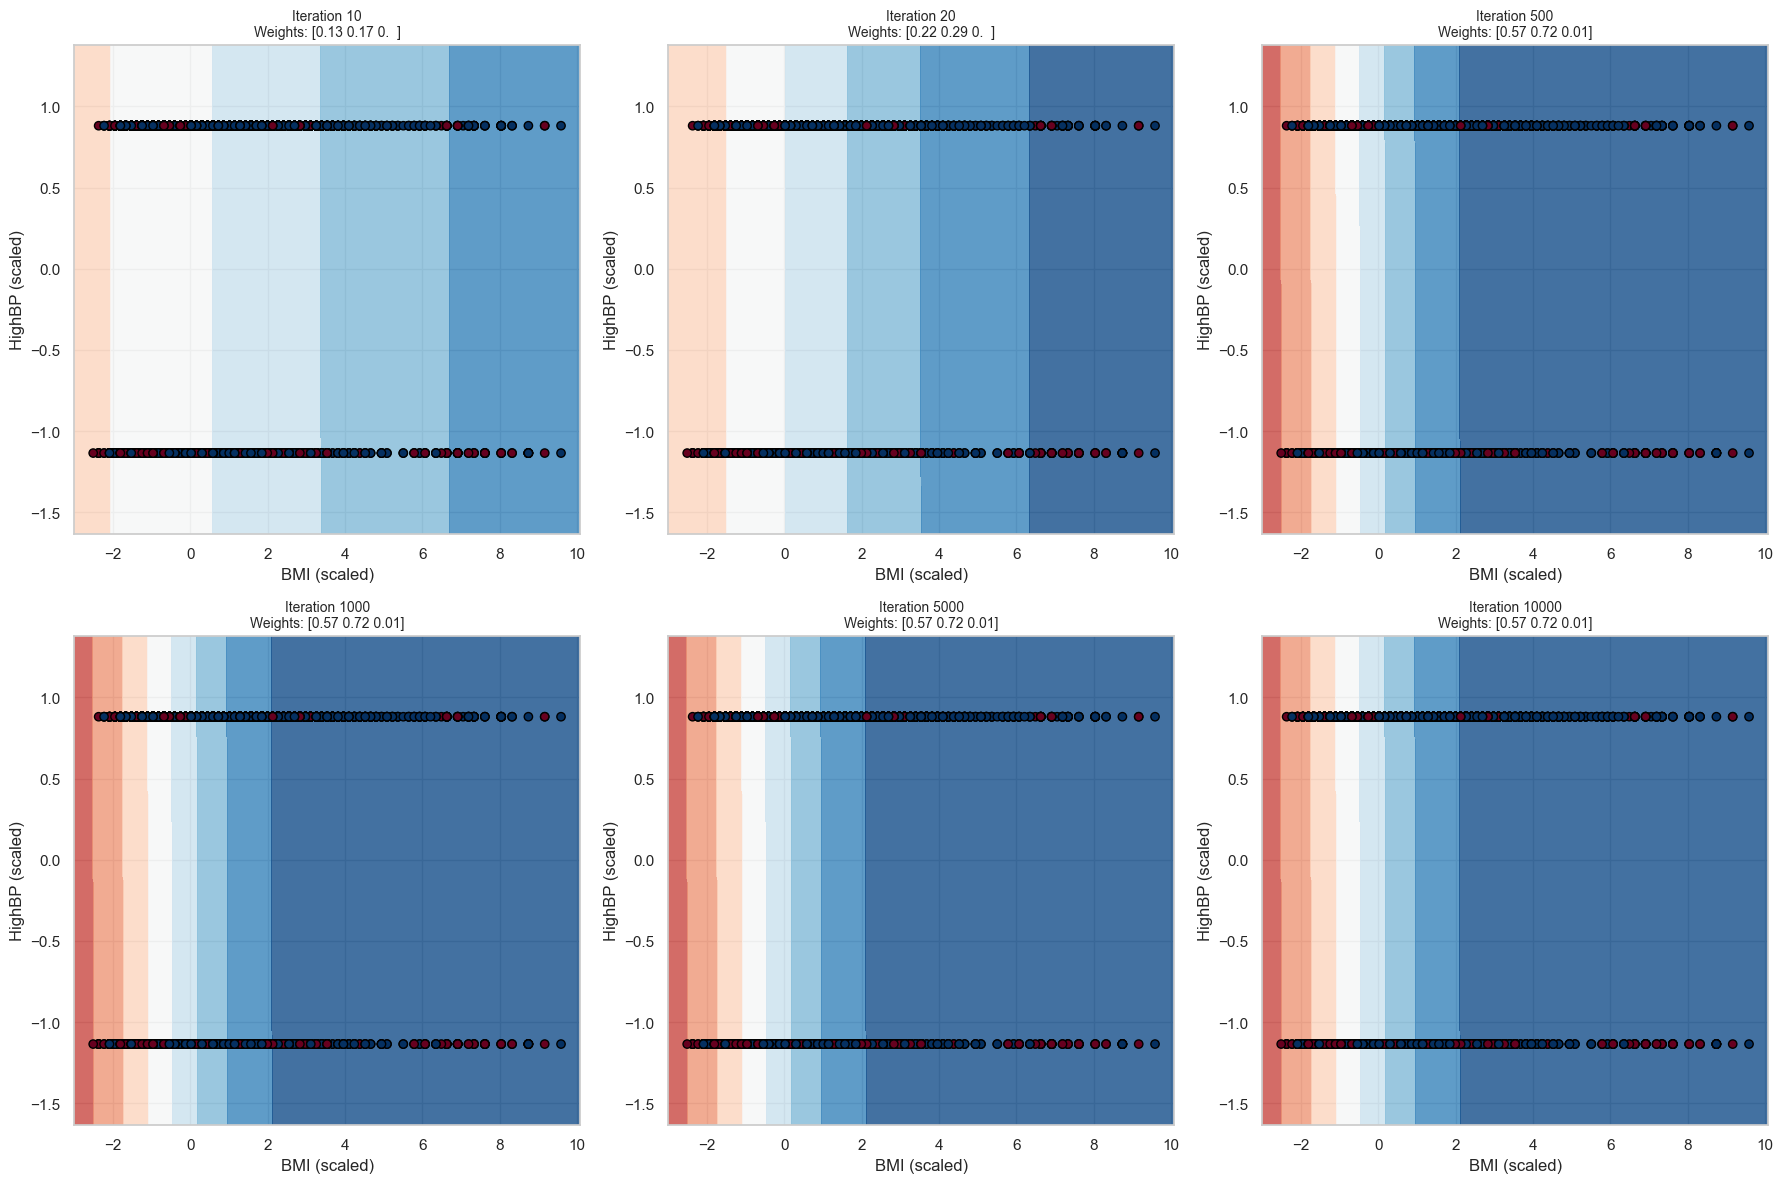

In [28]:
# Визуализация

# Создание сетки для визуализации
x_min, x_max = X_train_subset_scaled[:, 0].min() - 0.5, X_train_subset_scaled[:, 0].max() + 0.5
y_min, y_max = X_train_subset_scaled[:, 1].min() - 0.5, X_train_subset_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),  # 200 точек по оси X
    np.linspace(y_min, y_max, 200)   # 200 точек по оси Y
)

iters = [10, 20, 500, 1000, 5000, 10000]
plt.figure(figsize=(18, 12))

for idx, iter_num in enumerate(iters, 1):
    plt.subplot(2, 3, idx)
    
    if iter_num not in model.weights_history:
        continue  # Пропускаем итерации, которые не были сохранены
        
    weights = model.weights_history[iter_num]
    
    # Предсказание вероятностей для сетки
    Z = model._sigmoid(np.c_[xx.ravel(), yy.ravel()] @ weights[1:] + weights[0])
    Z = Z.reshape(xx.shape)
    
    # Визуализация
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu, levels=np.linspace(0, 1, 10))
    plt.scatter(
        X_train_subset_scaled[:, 0], 
        X_train_subset_scaled[:, 1], 
        c=y_train, 
        edgecolors="k", 
        cmap=plt.cm.RdBu
    )
    plt.title(f"Iteration {iter_num}\nWeights: {weights.round(2)}", fontsize=10)
    plt.xlabel("BMI (scaled)"), plt.ylabel("HighBP (scaled)")

plt.tight_layout()
plt.show()

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- da9c6c1a8068b61752e22c8d3afc9f51 -->
**Вывод:**

С увеличением итераций обучения модель более тонко (подробно) разграничивает предсказания. Также бросается в глаза, что на 10 - 20 итерациях модель стремительно обучается, а после 500 итерации она уже почти не изменяет предсказания.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- d11a6aa59c615661078a02a0c9fe90c8 -->
---
### Задача 6.

В этой задаче вам предлагается реализовать регрессию Хьюбера, а также применить ее к данным с выбросами. Для начала реализуйте класс по шаблону снизу. Обратите внимание, что класс `HuberRegression` &mdash; наследник класса `BaseEstimator`, это с легкостью позволит использовать наш класс в различных пайплайнах библиотеки `sklearn`.

**1.** Задача оптимизации для регрессии Хьюбера выглядит следующим образом:
$$\sum_{i=1}^n R\left(Y_i - x_i^T\theta\right) \rightarrow \min_\theta,$$
где $R(x)$ &mdash; функция потерь Хьюбера, определяемая как
$$R(x) = \frac{x^2}{2} I\left\{|x| < c\right\} + c \left(|x| - \frac{c}{2}\right)I\left\{|x| > c\right\}.$$

Выпишите формулы для градиентного и стохастического градиентного спусков. В чем польза такой функции потерь?


**Градиент функции потерь**:
$$
\nabla R(x) = \begin{cases} 
x & \text{если } |x| \leq c \\
c \cdot \text{sign}(x) & \text{если } |x| > c 
\end{cases}
$$

**Градиентный спуск (GD)**:
1. Вычисляем ошибку: $r_i = Y_i - x_i^T\theta$
2. Обновляем веса: $\theta_{new} = \theta_{old} - \eta \cdot \frac{1}{n} \sum_{i=1}^n \nabla R(r_i) \cdot x_i$

**Стохастический градиентный спуск (SGD)**:
1. Для батча $B \subset \{1, \dots, n\}$:
2. Вычисляем ошибку: $r_i = Y_i - x_i^T\theta$ для $i \in B$
3. Обновляем веса: $\theta_{new} = \theta_{old} - \eta \cdot \frac{1}{|B|} \sum_{i \in B} \nabla R(r_i) \cdot x_i$

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 7564b9fdf7abe57af71d5144cdd94483 -->
**2.** Реализуем теперь класс. **При реализации класса запрещено пользоваться ИИ-инструментами.**

In [31]:
class HuberRegression(BaseEstimator):
    """Класс, реализующий линейную регрессию с функцией потерь Хьюбера."""

    def __init__(self, c: float = 1.0, fit_intercept: bool = True, max_iter: int = 1000) -> None:
        """Инициализирует модель.

        Параметры: c (float): Константа из функции потерь Хьюбера.
        fit_intercept (bool): Добавлять ли константный признак. max_iter
        (int): Максимальное число итераций оптимизации.
        """
        self.c = c
        self.fit_intercept = fit_intercept
        self.max_iter = max_iter

    def _huber_loss(self, x):
        """Вычисляет значение и градиент функции Хьюбера."""
        abs_x = np.abs(x)
        mask = abs_x <= self.c
        loss = np.where(mask, 0.5 * x**2, self.c * (abs_x - 0.5 * self.c))
        grad = np.where(mask, x, self.c * np.sign(x))
        return loss, grad

    def fit(self, X: np.ndarray, y: np.ndarray) -> "HuberRegression":
        """Обучает модель.

        Параметры:
        X (np.ndarray): Матрица признаков.
        y (np.ndarray): Вектор целевой переменной.

        Возвращает:
        HuberRegression: Обученная модель.
        """
        if X.shape[0] != y.shape[0]:
            raise ValueError("Количество строк в X и y должно совпадать")

        # Добавляем константный признак если нужно
        X_copy = X.copy()
        if self.fit_intercept:
            X_copy = np.column_stack([X_copy, np.ones(X_copy.shape[0])])

        # Инициализация параметров
        n_features = X_copy.shape[1]
        theta = np.zeros(n_features)
        
        # Градиентный спуск
        for i in range(self.max_iter):
            residuals = y - X_copy.dot(theta)
            _, grad = self._huber_loss(residuals)
            gradient = -X_copy.T.dot(grad) / X_copy.shape[0]
            theta -= 0.01 * gradient  # Фиксированный learning rate

        # Сохраняем коэффициенты
        if self.fit_intercept:
            self.coef_ = theta[:-1]
            self.intercept_ = theta[-1]
        else:
            self.coef_ = theta
            self.intercept_ = 0.0
            
        self.n_iter_ = i + 1

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Делает предсказание на новых данных.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Вектор предсказанных значений.
        """
        X_copy = X.copy()
        if self.fit_intercept:
            X_copy = np.column_stack([X_copy, np.ones(X_copy.shape[0])])

        if X_copy.shape[1] != len(self.coef_) + (1 if self.fit_intercept else 0):
            raise ValueError("Число признаков в X не соответствует числу коэффициентов модели")

        pred = X_copy.dot(np.append(self.coef_, self.intercept_)) if self.fit_intercept else X_copy.dot(self.coef_)
        return pred

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 6a5cd74170aac817f849878e6dc1d059 -->
**3.** Загрузите данные из файлов `train.csv`, `test.csv`. Не забудьте, что всю аналитику, а также процесс обучения и подбор гиперпараметров необходимо выполнять на обучающей выборке.

In [32]:
train = pd.read_csv(r"D:\MIPT\Semester_4\AD\train.csv")
test = pd.read_csv(r"D:\MIPT\Semester_4\AD\test.csv")

Посмотрите на зависимость целевой переменной от каждого признака.

   feature_1  feature_2  feature_3      target
0   2.320800  -1.098571   0.117091  162.910894
1   0.625119  -0.782367  -0.813596   21.113006
2  -0.807648  -0.185054  -1.446535  -36.128990
3  -0.291837  -1.616474  -0.761492  -56.474495
4   0.938747   0.087531   0.607112  189.589573
   feature_1  feature_2  feature_3      target
0  -0.704700   2.256723   0.943261  245.538820
1   0.820248  -1.054628   0.463130  108.929550
2  -0.888971  -1.681218   0.242118  -13.787683
3  -1.226196  -0.375147   0.183339   37.905525
4  -1.029935   0.220508  -0.349943   45.853628
feature_1    0
feature_2    0
feature_3    0
target       0
dtype: int64
feature_1    0
feature_2    0
feature_3    0
target       0
dtype: int64


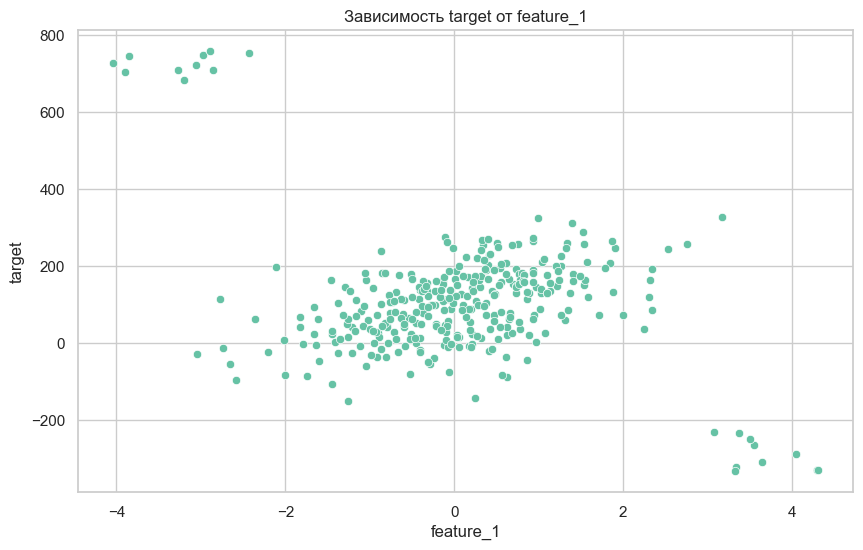

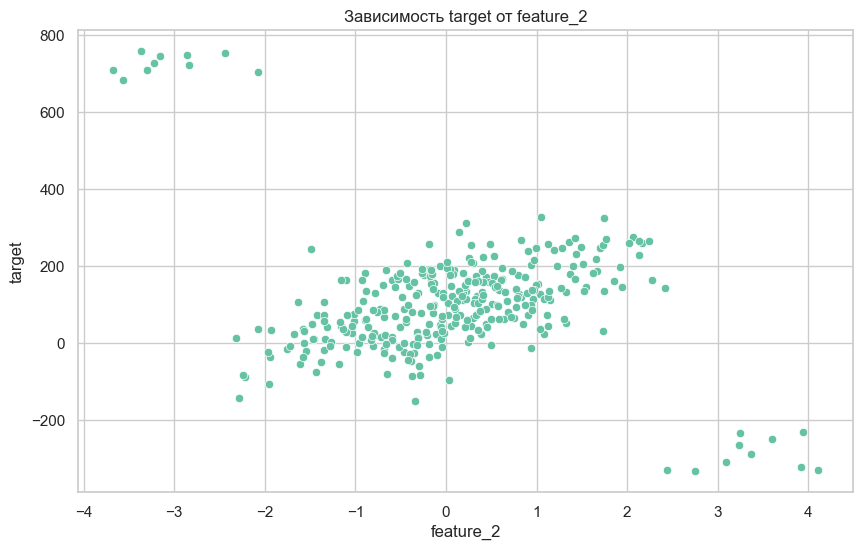

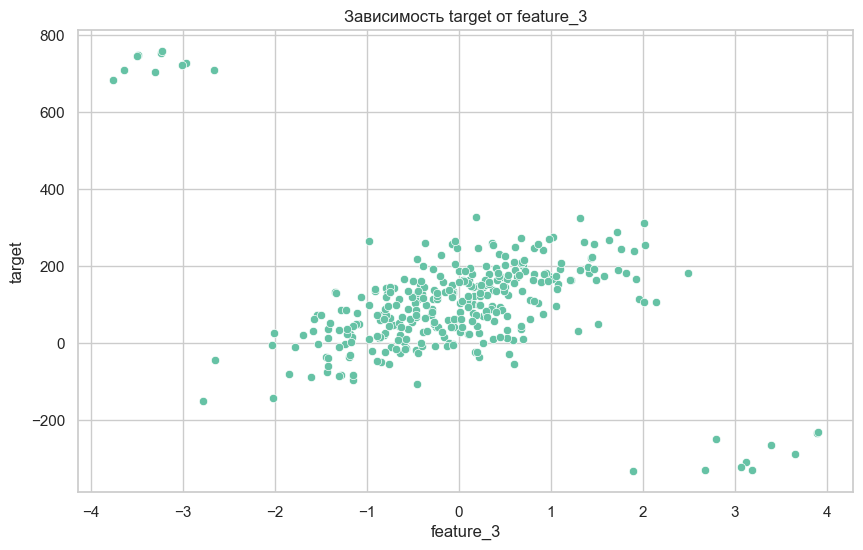

In [33]:
# Просмотр первых нескольких строк данных
print(train.head())
print(test.head())

# Проверка наличия пропущенных значений
print(train.isnull().sum())
print(test.isnull().sum())

# Визуализация зависимости целевой переменной от каждого признака
target_variable = 'target'  # Укажите имя целевой переменной

# Построение графиков для каждого признака
for column in train.columns:
    if column != target_variable:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(x=train[column], y=train[target_variable])
        plt.title(f'Зависимость {target_variable} от {column}')
        plt.xlabel(column)
        plt.ylabel(target_variable)
        plt.show()

Что можно сказать о наличии возможных выбросов? Какое влияние они могут оказать? 



На модели линейной регрессии:
Выбросы могут значительно искажать коэффициенты регрессии, так как модель будет пытаться минимизировать влияние выбросов, это приведет к неточным предсказаниям.


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 4a0c605a165e9e55e65c095ad5963e4c -->
**4.** Обучите простую линейную регрессию и посчитайте качество на тестовой выборке по метрике [MSE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html#sklearn.metrics.mean_squared_error).

In [40]:
# Разделение данных на признаки и целевую переменную
X_train = train[['feature_1', 'feature_2', 'feature_3']]
y_train = train['target']
X_test = test[['feature_1', 'feature_2', 'feature_3']]
y_test = test['target']

# Обучение модели линейной регрессии
model = LinearRegression()
model.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred = model.predict(X_test)

# Расчет MSE
mse = mean_squared_error(y_test, y_pred)
print(f"MSE на тестовой выборке: {mse:.2f}")

MSE на тестовой выборке: 17025.81


Что можно сказать о качестве нашей модели?

Есть большая проблема с моделью. 

**5.** Теперь обучите линейную регресcию Хьюбера и посчитайте качество на тестовой части по метрикe MSE.

In [41]:
# Инициализация и обучение модели Хьюбера
huber_model = HuberRegression(c=1.0, fit_intercept=True, max_iter=10000)
huber_model.fit(X_train.values, y_train.values)  # Используем .values для преобразования в numpy array

# Предсказание на тестовых данных
y_pred_huber = huber_model.predict(X_test.values)

# Расчет MSE
mse_huber = mean_squared_error(y_test, y_pred_huber)
print(f"MSE модели Хьюбера: {mse_huber:.2f}")

MSE модели Хьюбера: 7467.42


Что изменилось?

MSE кратно уменьшилась.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 2154c451eb280ed839063dce469f6931 -->
**6.** Для обучающей выборки постройте два графика (по графику на каждую модель), на которых изобразите зависимость истинного и предсказанного значения таргета от каждого признака.

In [42]:
# Предсказания моделей на обучающей выборке
y_pred_linear = model.predict(X_train.values)
y_pred_huber = huber_model.predict(X_train.values)

# Фиксируем остальные признаки на средних значениях
fixed_values = X_train.mean().values

C:\Users\Name\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [43]:
# Создаем сетку значений для каждого признака
def create_grid_for_feature(feature_col, n_points=100):
    feature_min = X_train[feature_col].min()
    feature_max = X_train[feature_col].max()
    return np.linspace(feature_min, feature_max, n_points)

C:\Users\Name\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Name\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Name\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


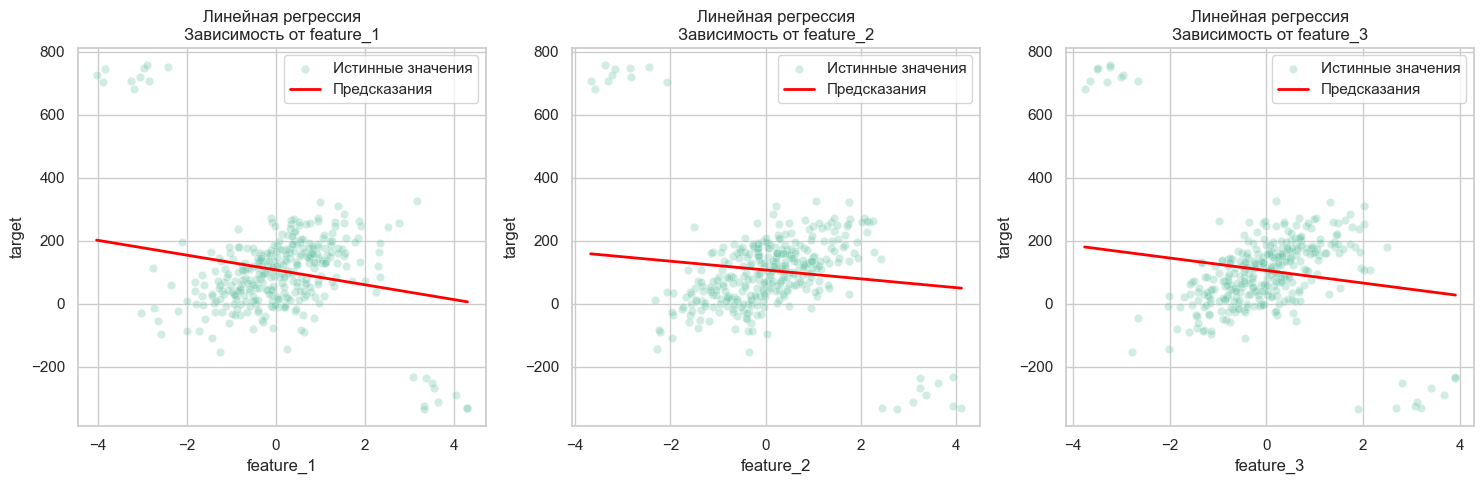

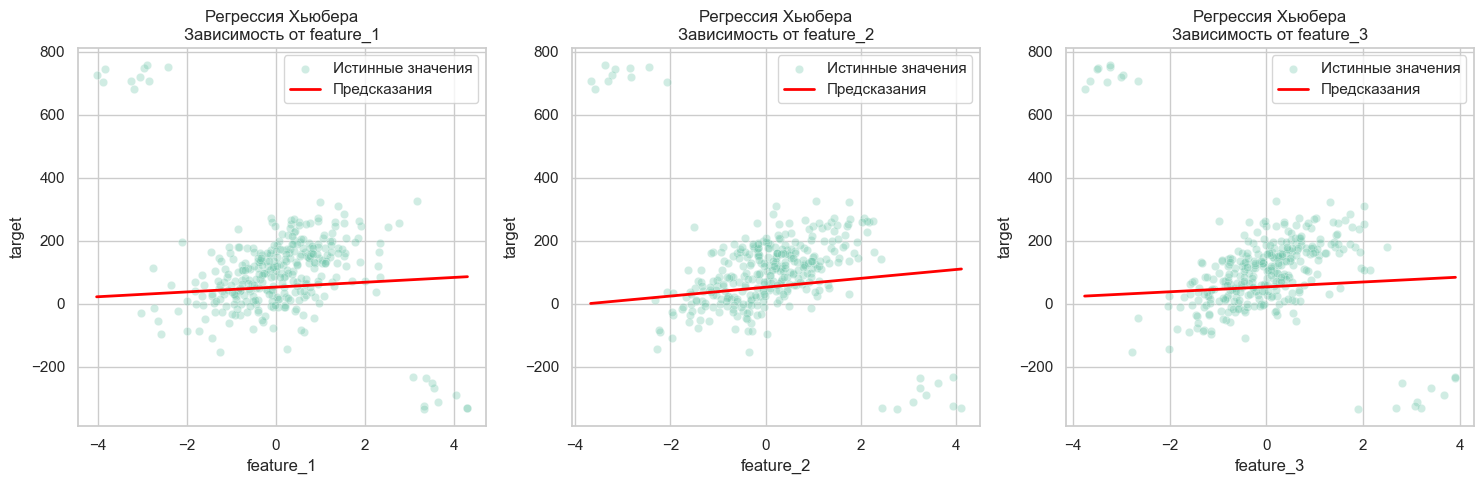

In [44]:
# Построение графиков для каждой модели и каждого признака
features = ['feature_1', 'feature_2', 'feature_3']

for model_name, y_pred in [('Линейная регрессия', y_pred_linear), 
                          ('Регрессия Хьюбера', y_pred_huber)]:
    plt.figure(figsize=(15, 5))
    for idx, feature in enumerate(features, 1):
        # Сетка значений для текущего признака
        grid = create_grid_for_feature(feature)
        
        # Матрица с фиксированными значениями остальных признаков
        X_grid = np.tile(fixed_values, (len(grid), 1))
        X_grid[:, features.index(feature)] = grid
        
        # Предсказания для сетки
        y_grid = model.predict(X_grid) if model_name == 'Линейная регрессия' else huber_model.predict(X_grid)
        
        # График
        plt.subplot(1, 3, idx)
        sns.scatterplot(x=X_train[feature], y=y_train, alpha=0.3, label='Истинные значения')
        sns.lineplot(x=grid, y=y_grid, color='red', linewidth=2, label='Предсказания')
        plt.title(f'{model_name}\nЗависимость от {feature}')
        plt.xlabel(feature)
        plt.ylabel('target')
        plt.legend()
    
    plt.tight_layout()
    plt.show()

Что можно заметить на этих графиках?

Линейная регрессия считает, что зависимость убывающая, а регрессия Хьюберта, что возрастающая. Это наглядный пример различных реакций на выбросы.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 90cceb512579b67df499239e31ee0e3a -->
**7.** Обучите регрессию Хьюбера на данных из задачи 2 и сравните качество модели с простой линейной регрессией, которую вы построили в задаче 2.

In [45]:
# Загрузка данных в day
day = pd.read_csv(r"D:\MIPT\Semester_4\AD\bike+sharing+dataset\day.csv")
day.head()

# Деление на нужные признаки
day = day[["season", "mnth", "holiday", "weekday", "workingday", "weathersit", "temp", "atemp", "hum", "windspeed", "cnt"]]

# Деление на тренировочную и тестовую выборки
train_day, test_day = train_test_split(day, train_size = 0.8, random_state=42)

Регрессия Хьюбера (MSE): 5188409.99


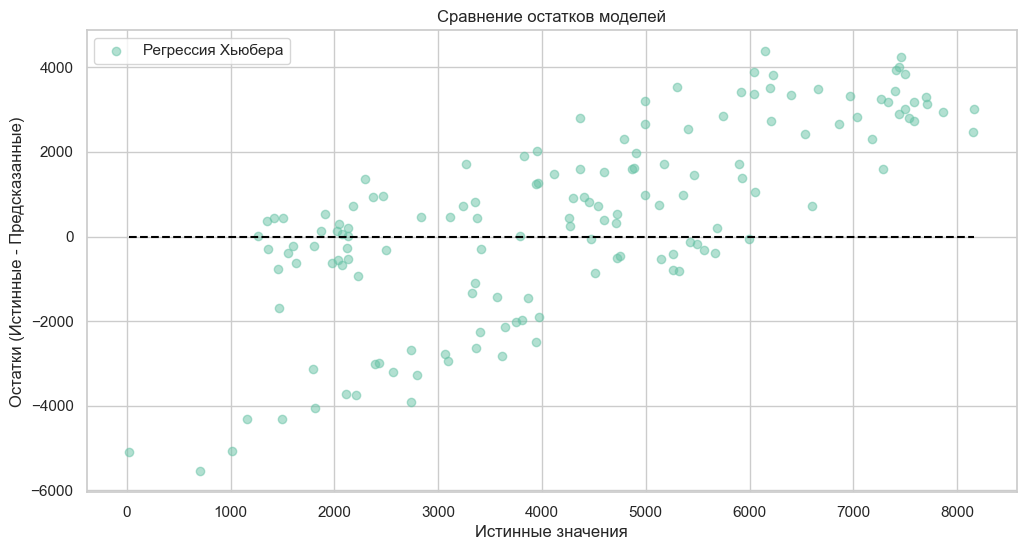

In [48]:
# Подготовка данных
X_train = train_day.drop(columns=["cnt"])
y_train = train_day["cnt"]
X_test = test_day.drop(columns=["cnt"])
y_test = test_day["cnt"]

# Обучение регрессии Хьюбера
huber_model = HuberRegression(c=1.0, fit_intercept=True, max_iter=10000)
huber_model.fit(X_train.values, y_train.values)
y_pred_huber = huber_model.predict(X_test.values)
mse_huber = mean_squared_error(y_test, y_pred_huber)

print(f"Регрессия Хьюбера (MSE): {mse_huber:.2f}")

# Визуализация
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_test - y_pred_huber, alpha=0.5, label="Регрессия Хьюбера")
plt.plot([y_test.min(), y_test.max()], [0, 0], "k--")
plt.xlabel("Истинные значения")
plt.ylabel("Остатки (Истинные - Предсказанные)")
plt.title("Сравнение остатков моделей")
plt.legend()
plt.show()

**Вывод:**

Регрессия Хьюбера получилась несравнимо хуже по оценке MSE.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 38dcbf8dc11db564c7513c7f0e5c8e0d -->
---
### Задача 7.


Рассмотрим модель одномерной регрессии $y(x) = \theta x$, где $x \in \mathbb{R}$ &mdash; одномерный признак, $y \in \mathbb{R}$ &mdash; целевой признак, $\theta \in \mathbb{R}$ &mdash; неизвестный параметр. Имеется выборка размера $n$, полученная по правилу
	$$Y_i = \theta x_i + \varepsilon_i,\ \ \ i=1,...,n,$$
где $\varepsilon_i$ &mdash; случайная ошибка измерений.

Предложите точный алгоритм поиска оценки параметра $\theta$ методом наименьших модулей, то есть $$\sum_{i=1}^n \left|Y_i - \theta x_i\right| \to \min_\theta,$$ работающий за время $O(n \log n)$. Приведите его описание и теоретическое обоснование. Реализация в коде не требуется.

**Решение:**

Игнорируем все точки, где $$x_i = 0.$$
Для остальных точек вычисляем $$Z_i = \frac{Y_i}{x_i}.$$
Сортируем массив $${Z_1, Z_2, \dots, Z_n}$$ по возрастанию. Это занимает $$O(n log n)$$ времени.
Находим медиану отсортированного массива. Если количество элементов нечётное, медиана — среднее арифметическое двух центральных элементов.
Оценка параметра $$\theta$$ равна найденной медиане.


Задача минимизации $$\sum_{i=1}^n |Y_i - \theta x_i|$$ эквивалентна минимизации $$\sum_{i=1}^n |Z_i - \theta|$$. Функция $$f(\theta) = \sum_{i=1}^n |Z_i - \theta|$$ является выпуклой и достигает минимума в медиане значений $$Z_i$$. Сортировка — наиболее вычислительно сложная операция, определяющая общую сложность $$O(n log n)$$.